In [1]:
# =========================
# 1) Mount Google Drive
# =========================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# =========================
# Batch LIGHT DSP for Baseline
# =========================

!pip install -q librosa soundfile scipy numpy

import os
import numpy as np
import librosa
import soundfile as sf
from scipy.signal import butter, filtfilt

# =========================
# FOLDERS
# =========================
input_folder = "/content/drive/MyDrive/MusicGen_Project/Data/MusicGen_Output"
output_folder = "/content/drive/MyDrive/MusicGen_Project/Data/DSP_Output"
os.makedirs(output_folder, exist_ok=True)

# =========================
# SETTINGS
# =========================
remove_dc = True

use_highpass = True
highpass_cutoff_hz = 25.0
highpass_order = 2

target_peak = 0.95
hard_clip_safety = 0.999

# =========================
# HELPER FUNCTIONS
# =========================
def remove_dc_offset(y):
    if y.ndim == 1:
        return y - np.mean(y)
    else:
        return y - np.mean(y, axis=0, keepdims=True)

def highpass_filter(y, sr, cutoff_hz=25.0, order=2):
    nyquist = 0.5 * sr
    norm_cutoff = cutoff_hz / nyquist
    b, a = butter(order, norm_cutoff, btype="highpass")

    if y.ndim == 1:
        return filtfilt(b, a, y)
    else:
        y_filt = np.zeros_like(y)
        for ch in range(y.shape[1]):
            y_filt[:, ch] = filtfilt(b, a, y[:, ch])
        return y_filt

def peak_normalize(y, target_peak=0.95):
    peak = np.max(np.abs(y))
    if peak > 0:
        y = y * (target_peak / peak)
    return y

# =========================
# PROCESS ALL FILES
# =========================
files = [f for f in os.listdir(input_folder) if f.endswith(".wav")]
print("Found files:", len(files))

for file in files:
    input_path = os.path.join(input_folder, file)
    output_name = file.replace(".wav", "_DSP.wav")
    output_path = os.path.join(output_folder, output_name)

    # Load audio
    y, sr = librosa.load(input_path, sr=None, mono=False)

    # Convert to (samples, channels)
    if y.ndim == 2:
        y = y.T

    # 1) Remove DC offset
    if remove_dc:
        y = remove_dc_offset(y)

    # 2) High-pass filter
    if use_highpass:
        y = highpass_filter(y, sr, cutoff_hz=highpass_cutoff_hz, order=highpass_order)

    # 3) Prevent clipping before normalization
    max_abs_before = np.max(np.abs(y))
    if max_abs_before > 1.0:
        y = y / max_abs_before

    # 4) Peak normalize
    y = peak_normalize(y, target_peak=target_peak)

    # 5) Final safety clip
    y = np.clip(y, -hard_clip_safety, hard_clip_safety)

    # Save
    sf.write(output_path, y, sr)

    print("Processed:", file)

print("All files processed.")

Found files: 30
Processed: piano_01.wav
Processed: piano_02.wav
Processed: piano_03.wav
Processed: piano_04.wav
Processed: piano_05.wav
Processed: guitar_01.wav
Processed: guitar_02.wav
Processed: guitar_03.wav
Processed: guitar_04.wav
Processed: guitar_05.wav
Processed: drums_01.wav
Processed: drums_02.wav
Processed: drums_03.wav
Processed: drums_04.wav
Processed: drums_05.wav
Processed: ambient_01.wav
Processed: ambient_02.wav
Processed: ambient_03.wav
Processed: ambient_04.wav
Processed: ambient_05.wav
Processed: electronic_01.wav
Processed: electronic_02.wav
Processed: electronic_03.wav
Processed: electronic_04.wav
Processed: electronic_05.wav
Processed: orchestral_01.wav
Processed: orchestral_02.wav
Processed: orchestral_03.wav
Processed: orchestral_04.wav
Processed: orchestral_05.wav
All files processed.


In [15]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

orig_path = "/content/drive/MyDrive/MusicGen_Project/Data/MusicGen_Output/guitar_01.wav"
rest_path = "/content/drive/MyDrive/MusicGen_Project/Data/DSP_Output2/guitar_01_DSP.wav"

y1, sr1 = librosa.load(orig_path, sr=None)
y2, sr2 = librosa.load(rest_path, sr=None)

print("Original sr:", sr1, "length:", len(y1)/sr1, "sec")
print("Restored sr:", sr2, "length:", len(y2)/sr2, "sec")

Original sr: 32000 length: 5.06 sec
Restored sr: 32000 length: 5.06 sec


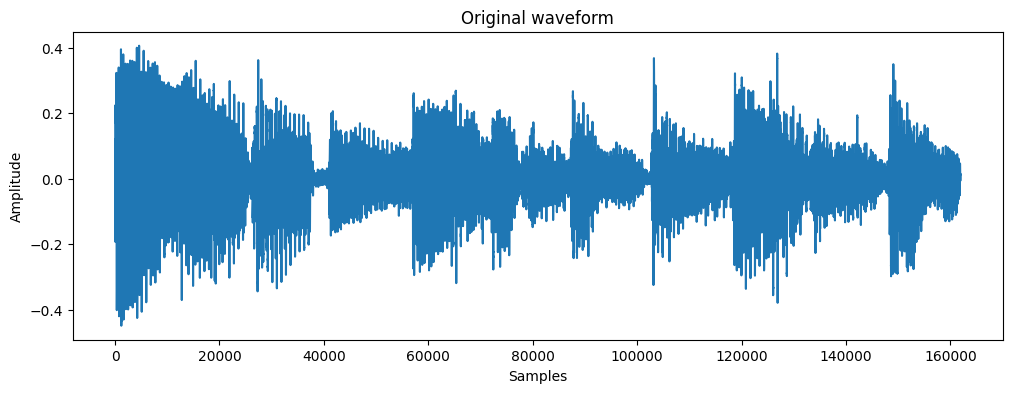

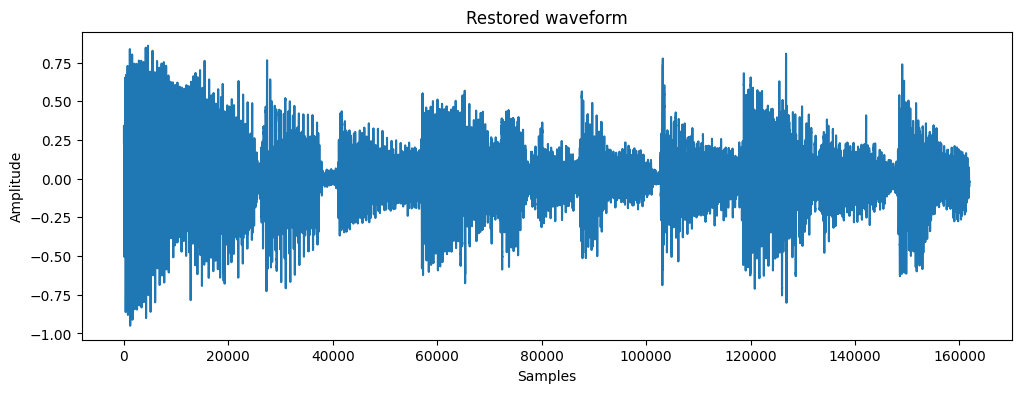

In [16]:
plt.figure(figsize=(12,4))
plt.plot(y1)
plt.title("Original waveform")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(y2)
plt.title("Restored waveform")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

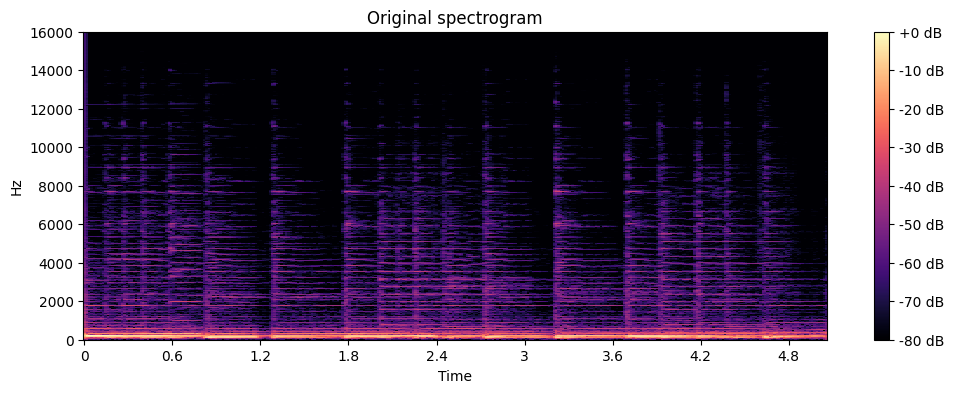

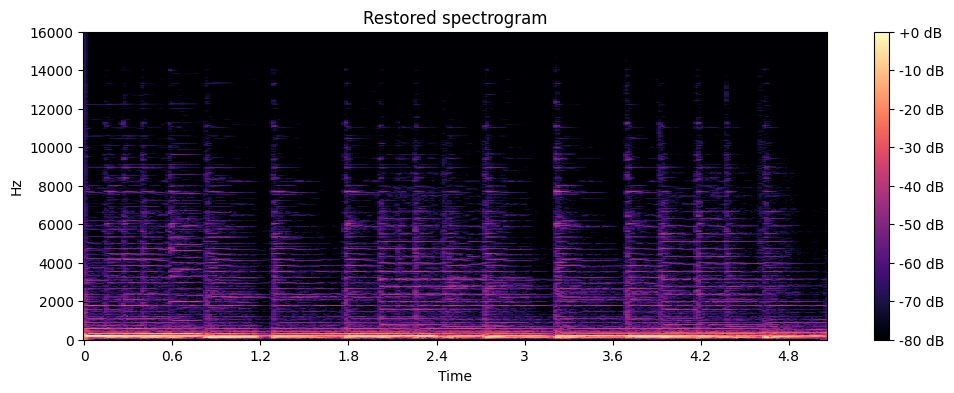

In [17]:
D1 = librosa.amplitude_to_db(np.abs(librosa.stft(y1)), ref=np.max)
D2 = librosa.amplitude_to_db(np.abs(librosa.stft(y2)), ref=np.max)

plt.figure(figsize=(12,4))
librosa.display.specshow(D1, sr=sr1, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title("Original spectrogram")
plt.show()

plt.figure(figsize=(12,4))
librosa.display.specshow(D2, sr=sr2, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title("Restored spectrogram")
plt.show()

In [18]:
y1, sr1 = librosa.load(orig_path, sr=None)
y2, sr2 = librosa.load(rest_path, sr=None)

min_len = min(len(y1), len(y2))
y1 = y1[:min_len]
y2 = y2[:min_len]

print("Same sample rate:", sr1 == sr2)
print("Same length:", len(y1) == len(y2))
print("Max abs difference:", np.max(np.abs(y1 - y2)))
print("Mean abs difference:", np.mean(np.abs(y1 - y2)))
print("All close:", np.allclose(y1, y2, atol=1e-6))

Same sample rate: True
Same length: True
Max abs difference: 0.5014343
Mean abs difference: 0.08071594
All close: False
